1

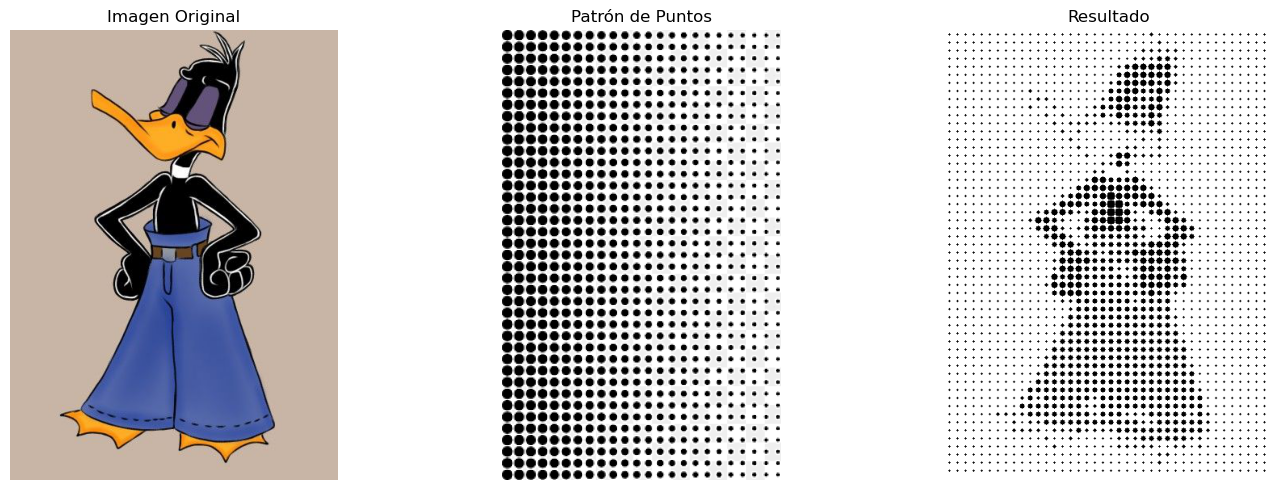

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 



pato = cv2.imread('pato.jpg')
patron_puntos = cv2.imread('puntos.png', 0) 


if pato is None or patron_puntos is None:
    print("Error al cargar las imágenes")
else:
    
    pato_gris = cv2.cvtColor(pato, cv2.COLOR_BGR2GRAY)
    
    
    altura, anchura = pato_gris.shape
    patron_puntos_redim = cv2.resize(patron_puntos, (anchura, altura))
    
    
    pato_inv = 255 - pato_gris
    
    
    pato_norm = pato_inv / 255.0
    
    
    _, pato_bin = cv2.threshold(pato_gris, 127, 255, cv2.THRESH_BINARY)
    
    mapa_intensidad = cv2.normalize(pato_norm, None, 0, 1, cv2.NORM_MINMAX)
    
    
    resultado = np.ones((altura, anchura), dtype=np.uint8) * 255
    
    # Tamaño de la celda 
    tam_celda = 10
    filas = altura // tam_celda
    columnas = anchura // tam_celda
    
    # Procesar la imagen por celdas
    for i in range(filas):
        for j in range(columnas):
            y_inicio = i * tam_celda
            y_fin = min((i + 1) * tam_celda, altura)
            x_inicio = j * tam_celda
            x_fin = min((j + 1) * tam_celda, anchura)
            
            # Obtener la intensidad promedio en esta celda
            intensidad = np.mean(pato_norm[y_inicio:y_fin, x_inicio:x_fin])
            
            # Si la intensidad es mayor que un umbral, colocar un punto
            if intensidad > 0.2:  # Ajusta este umbral según sea necesario
                radio = int(intensidad * tam_celda / 2)
                cv2.circle(resultado, 
                           (x_inicio + tam_celda // 2, y_inicio + tam_celda // 2), 
                           radio, 0, -1)
    
    # Mostrar resultados
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title('Imagen Original')
    plt.imshow(cv2.cvtColor(pato, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title('Patrón de Puntos')
    plt.imshow(patron_puntos, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.title('Resultado')
    plt.imshow(resultado, cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

2. cuantos objetos de cada color hay en la imagen

Objetos contados por color:
Rojo: 7
Naranja: 10
Amarillo: 6
Verde: 10
Azul: 7


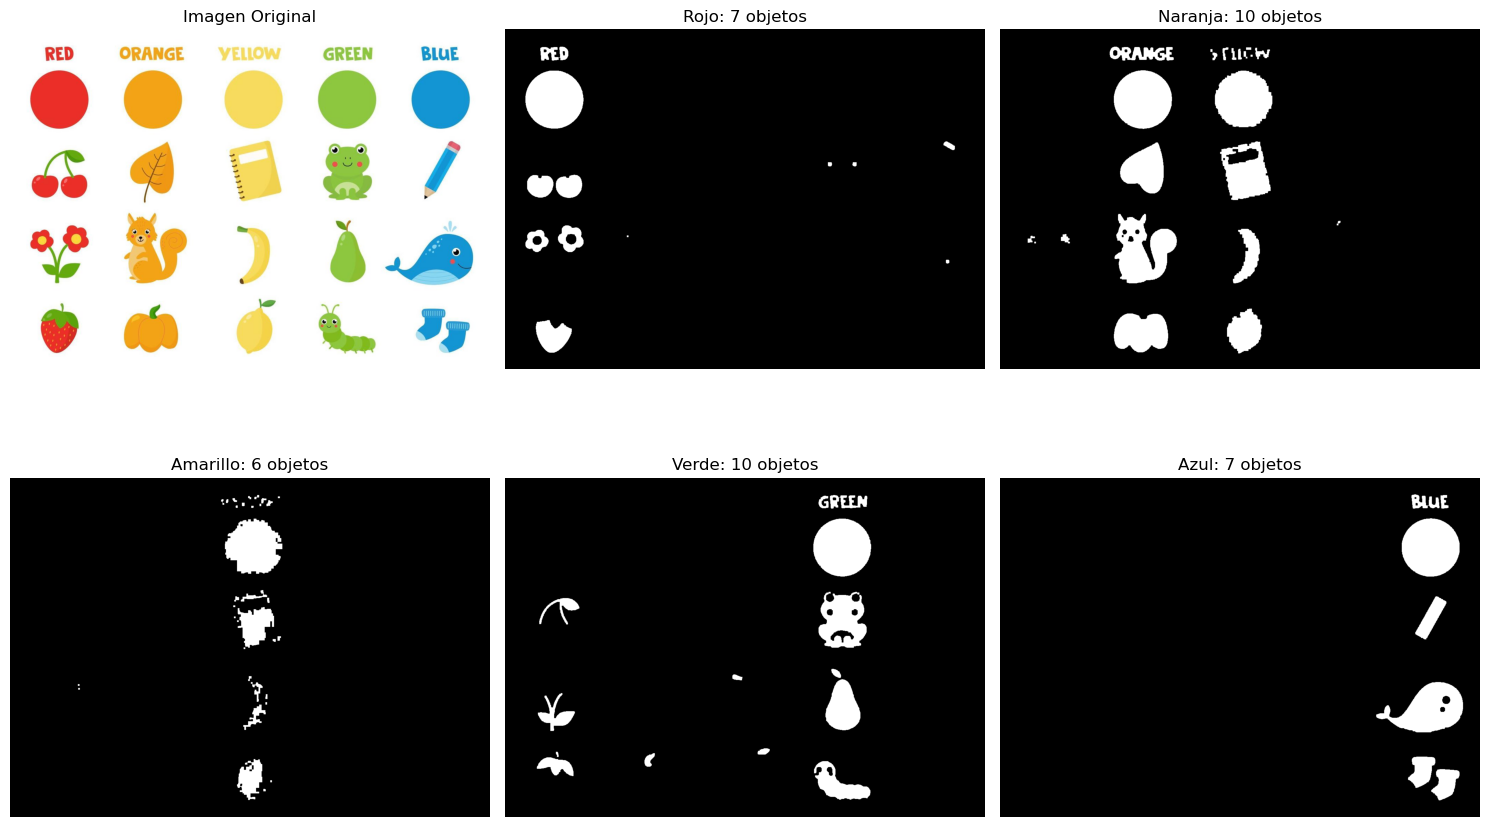

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def count_by_color(img):
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    
    # Defir rangos de colores en HSV
    color_ranges = {
        'rojo': ([0, 100, 100], [10, 255, 255], [160, 100, 100], [180, 255, 255]),  # Red has two ranges in HSV
        'naranja': ([10, 100, 100], [25, 255, 255]),
        'amarillo': ([25, 100, 100], [35, 255, 255]),
        'verde': ([35, 100, 100], [85, 255, 255]),
        'azul': ([85, 100, 100], [125, 255, 255]),
    }
    
    results = {}
    color_masks = {}
    
    
    for color, ranges in color_ranges.items():
        # Crear mascara por cada color
        if color == 'rojo':  # rojo quiere 2 rangos
            lower1, upper1, lower2, upper2 = ranges
            mask1 = cv2.inRange(img_hsv, np.array(lower1), np.array(upper1))
            mask2 = cv2.inRange(img_hsv, np.array(lower2), np.array(upper2))
            mask = cv2.bitwise_or(mask1, mask2)
        else:
            lower, upper = ranges
            mask = cv2.inRange(img_hsv, np.array(lower), np.array(upper))
        
        # quitar ruido
        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        
        # Encontrar contornos
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        
        valid_contours = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area > 500:  # Adjusta el área mínima según sea necesario
                valid_contours.append(cnt)
        
        # guar
        results[color] = len(valid_contours)
        color_masks[color] = mask
    
    return results, color_masks


imagen = cv2.imread("colores.jpg")


counts, masks = count_by_color(imagen)


print("Objetos contados por color:")
for color, count in counts.items():
    print(f"{color.capitalize()}: {count}")


plt.figure(figsize=(15, 10))


plt.subplot(2, 3, 1)
plt.title("Imagen Original")
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.axis('off')


colors = ['rojo', 'naranja', 'amarillo', 'verde', 'azul']
for i, color in enumerate(colors):
    plt.subplot(2, 3, i+2)
    plt.title(f"{color.capitalize()}: {counts[color]} objetos")
    plt.imshow(masks[color], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

3. Estás trabajando en un proyecto de reconocimiento de rostros y necesitas detectar los 
bordes de las caras en las imágenes. Explique cómo aplicaría el operador de detección de 
bordes de Canny y aplícalo con un código en Python en jupyter



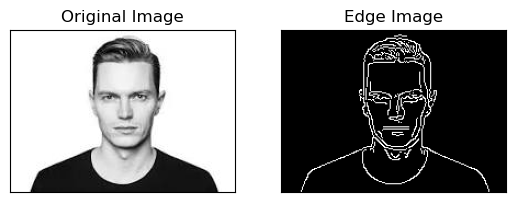

In [30]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
 
img = cv.imread('rostro001.jpeg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
edges = cv.Canny(img,100,200)
 
plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(edges,cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
 
plt.show()